# Is the model exported so the demo can run without the notebooks?

This notebook builds the model bundle and the reference prediction if they are
missing, reloads the bundle in a fresh Python process to reproduce that
prediction, and reads the replay files written by `experiments replay`. It
never touches the lockbox files. The replays are cached because each takes
about two minutes to build (fold refit).

**Main findings:** see the sizes and the reproduction result in the cells
below; they are printed from the saved files, not typed in.

In [1]:
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

from keyframe import paths, predict

paths.FIGURES.mkdir(parents=True, exist_ok=True)
bundle = paths.MODELS / predict.REFERENCE_FILE
if not (paths.MODELS / "keyframe_xgboost.joblib").exists() or not bundle.exists():
    predict.export_model()

/home/user/KeyFrame/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Files written and their sizes

In [2]:
replay_dir = paths.MODELS / "replays"
files = [
    *sorted(paths.MODELS.glob("*.joblib")),
    *sorted(paths.MODELS.glob("*.json")),
]
replay_files = sorted(replay_dir.glob("*.json"))
sizes = pd.DataFrame(
    {"file": [f.name for f in files], "size_kb": [f.stat().st_size / 1024 for f in files]}
)
print(sizes.round(1).to_string(index=False))
replay_kb = [f.stat().st_size / 1024 for f in replay_files]
print(
    f"{len(replay_files)} replay files (incl. index), total {sum(replay_kb) / 1024:.1f} MB, "
    f"largest {max(replay_kb) / 1024:.2f} MB"
)

                     file  size_kb
  keyframe_xgboost.joblib    426.8
          model_meta.json     85.4
reference_prediction.json   1684.7
19 replay files (incl. index), total 20.7 MB, largest 1.66 MB


## Reproduction in a clean session

In [3]:
code = "from keyframe import predict; print(predict.reproduce_reference())"
result = subprocess.run([sys.executable, "-c", code], capture_output=True, text=True, check=True)
gap = float(result.stdout.strip().splitlines()[-1])
print(f"largest probability gap after reloading from disk in a new process: {gap:.2e}")
assert gap < 1e-6

largest probability gap after reloading from disk in a new process: 0.00e+00


## One replay run: traces, probabilities and the alarm

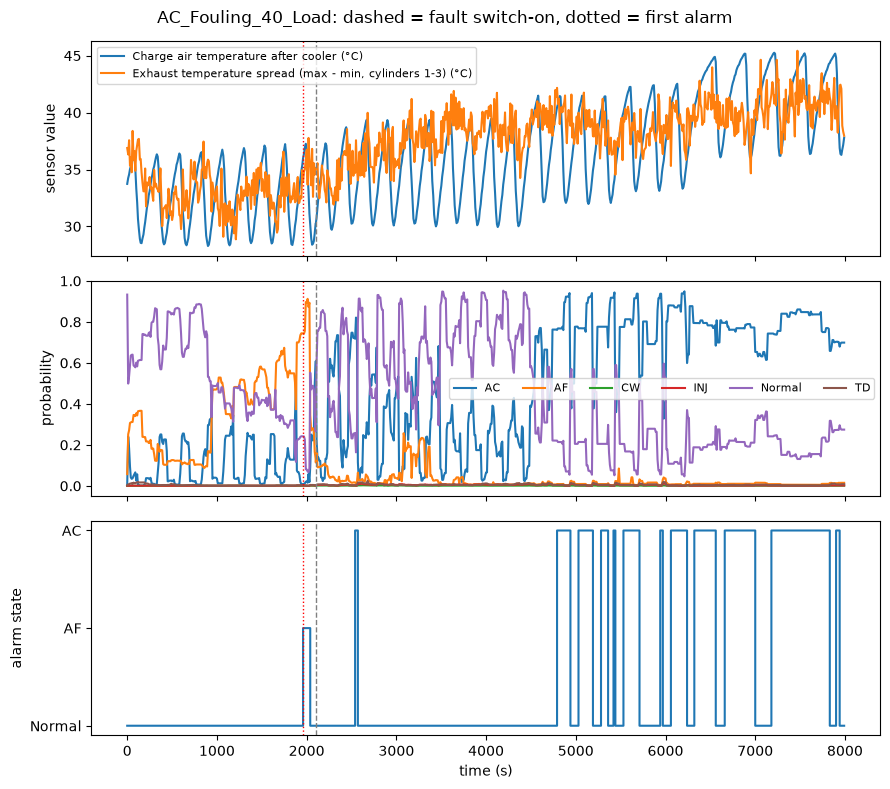

In [4]:
replay = json.loads((replay_dir / "AC_Fouling_40_Load.json").read_text())
frames = replay["frames"]
t = [f["t"] for f in frames]
classes = list(frames[0]["probabilities"])
switch_on = replay["switch_on_t"]
alarm_t = next((f["t"] for f in frames if f["alarm"] != "Normal"), None)

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for key in ("charge_air_temp_after_cooler", "exhaust_temp_spread"):
    axes[0].plot(
        t,
        [f["sensors"][key]["value"] for f in frames],
        label=f"{frames[0]['sensors'][key]['label']} ({frames[0]['sensors'][key]['unit']})",
    )
axes[0].set_ylabel("sensor value")
axes[0].legend(fontsize=8)
for c in classes:
    axes[1].plot(t, [f["probabilities"][c] for f in frames], label=c)
axes[1].set_ylabel("probability")
axes[1].legend(ncol=6, fontsize=8)
axes[2].step(t, [f["alarm"] for f in frames], where="post")
axes[2].set_ylabel("alarm state")
axes[2].set_xlabel("time (s)")
for ax in axes:
    if switch_on is not None:
        ax.axvline(switch_on, color="grey", linestyle="--", linewidth=1)
    if alarm_t is not None:
        ax.axvline(alarm_t, color="red", linestyle=":", linewidth=1)
fig.suptitle(f"{replay['run']}: dashed = fault switch-on, dotted = first alarm")
fig.tight_layout()
fig.savefig(paths.FIGURES / "08_replay_example.png", dpi=150)

## Findings

In [5]:
index = pd.DataFrame(json.loads((replay_dir / "index.json").read_text()))
delay = index["alarm_delay_s"]
print(
    f"model bundle {sizes.set_index('file').loc['keyframe_xgboost.joblib', 'size_kb']:.0f} KB; "
    f"reproduction gap {gap:.1e} (limit 1e-6); {len(index)} replays, "
    f"{int(delay.notna().sum())} alarmed, {int(delay.isna().sum())} never alarmed "
    f"(healthy references and faults the model misses)."
)
print(
    f"example run: switch-on {switch_on} s, first alarm at {alarm_t} s, "
    f"{len(frames)} frames of 10 s"
)

model bundle 427 KB; reproduction gap 0.0e+00 (limit 1e-6); 18 replays, 10 alarmed, 8 never alarmed (healthy references and faults the model misses).
example run: switch-on 2102.0 s, first alarm at 1960.0 s, 801 frames of 10 s
